### Name: EDWIN SUNDAY UMANA
Data Science Internship;

Week 1, Batch D
August

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
file = 'WA_Fn-UseC_-HR-Employee-Attrition.csv'
df = pd.read_csv(file)

In [4]:
print("--- first five rows of the data ---")
display(df.head())

--- first five rows of the data ---


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# Data Inspection

In [5]:
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns.\n")

Dataset Shape: 1470 rows and 35 columns.



In [6]:
print ("Columns Names:")
print (df.columns.tolist(), "\n")

Columns Names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager'] 



In [7]:
# checking for data types and non-null counts
print("Data Types and Information:")
df.info()
print("\n" + "="*50 + "\n")

Data Types and Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 

In [8]:
# Checking for missing values
print("Missing Values:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "NO missing values found" )


Missing Values:
NO missing values found


In [9]:
# Checking for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [10]:
# Descriptive statistics for numerical Columns
print("\nDescriptive Statistics (Numerical Columns):")
display(df.describe())


Descriptive Statistics (Numerical Columns):


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [11]:
# Descriptive Statistics for Categorical (text) Columns
print("\nDescriptive Statistics (Categorical Columns):")
display(df.describe(include=['object']))


Descriptive Statistics (Categorical Columns):


,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


**Part 3 : Initial data Exploration and visualisation**

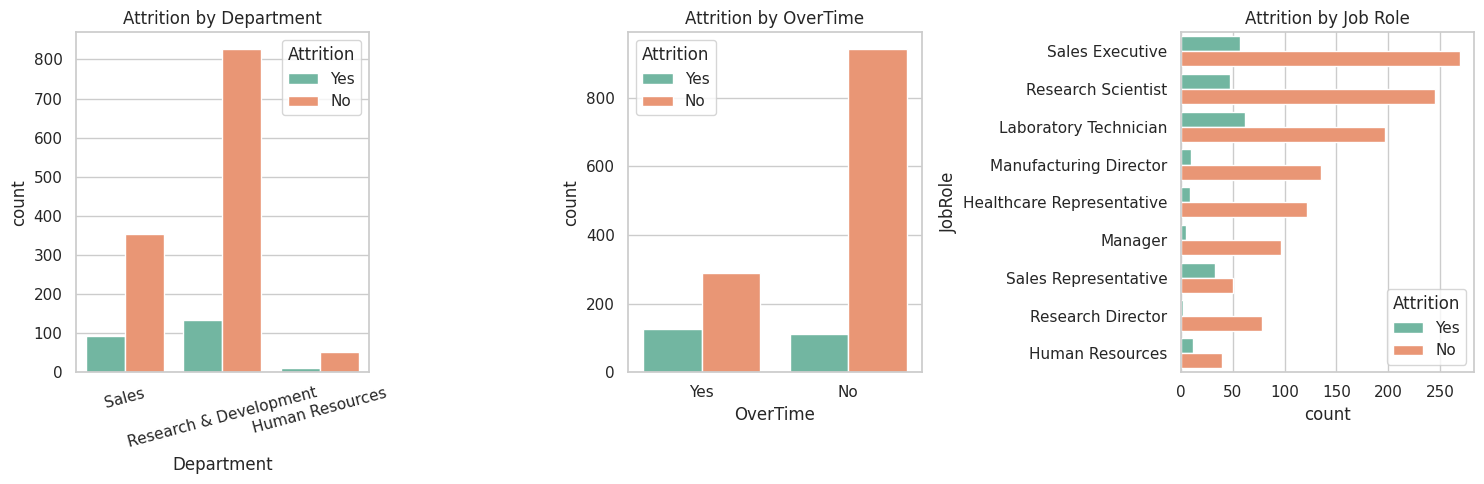

In [12]:
# --- BAR CHARTS ---
plt.figure(figsize=(15, 5))

# Bar Chart 1: Attrition by Department
plt.subplot(1, 3, 1)
sns.countplot(data=df, x='Department', hue='Attrition', palette='Set2')
plt.title('Attrition by Department')
plt.xticks(rotation=15)

# Bar Chart 2: Attrition by OverTime
plt.subplot(1, 3, 2)
sns.countplot(data=df, x='OverTime', hue='Attrition', palette='Set2')
plt.title('Attrition by OverTime')

# Bar Chart 3: Attrition by Job Role (Horizontal for better readability)
plt.subplot(1, 3, 3)
sns.countplot(data=df, y='JobRole', hue='Attrition', palette='Set2', order=df['JobRole'].value_counts().index)
plt.title('Attrition by Job Role')

plt.tight_layout()
plt.show()

### Interpretation of Bar Charts

**Bar Chart 1 – Attrition by Department:**
Research & Development has the largest workforce (over 800 employees), followed by Sales, while Human Resources is the smallest. Although R&D records the highest *number* of leavers, **Sales has the highest attrition *rate*** — roughly 1 in 5 Sales employees left, compared to about 1 in 7 in R&D. This suggests the Sales department has a more serious retention problem.

**Bar Chart 2 – Attrition by OverTime:**
Overtime is a strong indicator of attrition. About 30% of employees who worked overtime left the company, compared to only about 10% of those who did not. This suggests that heavy workload and long hours may be pushing employees to resign.

**Bar Chart 3 – Attrition by Job Role:**
Laboratory Technicians, Sales Executives and Research Scientists record the highest number of leavers, and Sales Representatives show high turnover relative to their small headcount. Managers and Research Directors (senior roles) have the lowest attrition, suggesting that seniority and career progression improve retention.

/tmp/ipykernel_616/46597927.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='Age', palette='Set3')
/tmp/ipykernel_616/46597927.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='Set3')


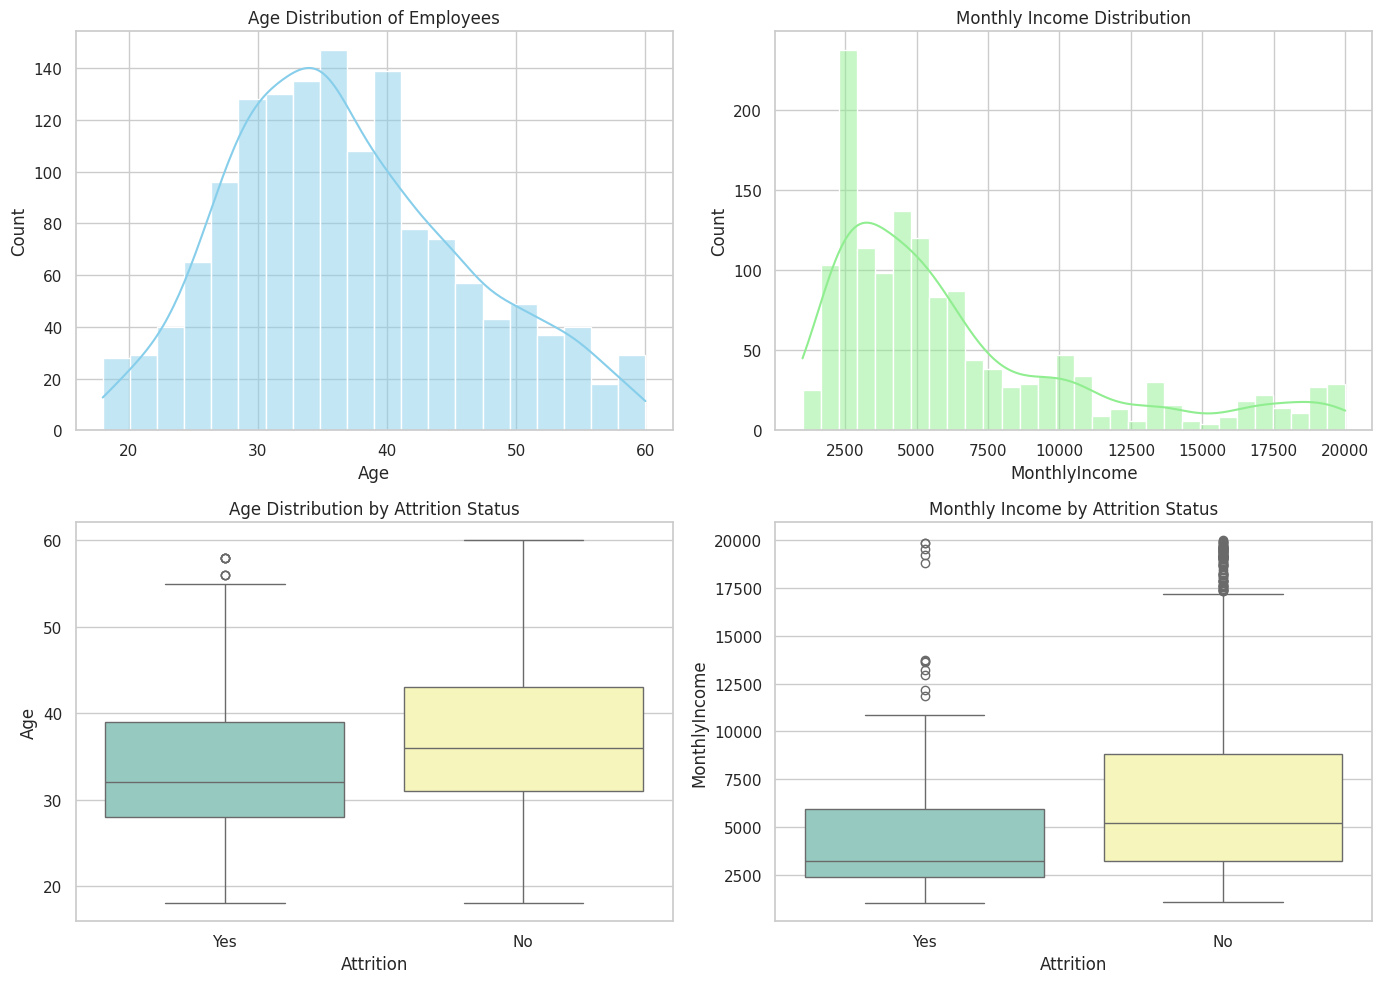

In [13]:
# --- HISTOGRAMS & BOXPLOTS ---
plt.figure(figsize=(14, 10))

# Histogram 1: Age Distribution
plt.subplot(2, 2, 1)
sns.histplot(data=df, x='Age', bins=20, kde=True, color='skyblue')
plt.title('Age Distribution of Employees')

# Histogram 2: Monthly Income Distribution
plt.subplot(2, 2, 2)
sns.histplot(data=df, x='MonthlyIncome', bins=30, kde=True, color='lightgreen')
plt.title('Monthly Income Distribution')

# Boxplot 1: Age vs Attrition
plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='Attrition', y='Age', palette='Set3')
plt.title('Age Distribution by Attrition Status')

# Boxplot 2: Monthly Income vs Attrition
plt.subplot(2, 2, 4)
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='Set3')
plt.title('Monthly Income by Attrition Status')

plt.tight_layout()
plt.show()

### Interpretation of Histograms and Boxplots

**Histogram 1 – Age Distribution:**
The workforce is relatively young. Most employees are between 25 and 45 years old, with a peak around 30–40 years and an average age of about 37. Very few employees are above 55 years.

**Histogram 2 – Monthly Income Distribution:**
The income distribution is right-skewed. The majority of employees earn between $\$2,000$ and $\$5,000$ per month, while only a small number earn above $10,000. This shows that most of the workforce is in junior to mid-level pay bands.

**Boxplot 1 – Age vs Attrition:**
Employees who left the company are generally **younger**. The median age of leavers (around 30–32 years) is clearly lower than that of employees who stayed (around 36 years). Younger employees are therefore more at risk of attrition.

**Boxplot 2 – Monthly Income vs Attrition:**
Employees who left have a **lower median monthly income** (below $\$3,000$) compared to those who stayed (around $\$5,000$). Lower-paid employees are more likely to resign, which suggests that compensation is an important retention factor.

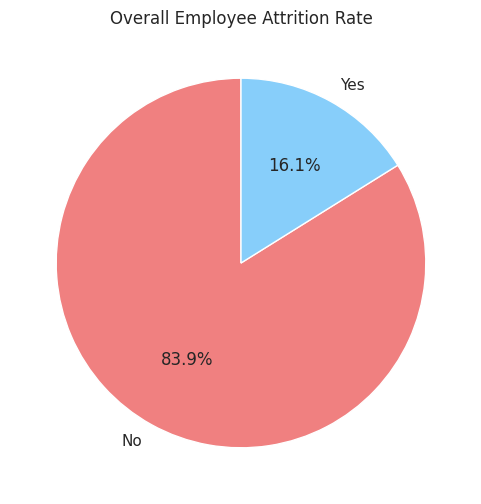

In [14]:
# --- PIE CHART ---
plt.figure(figsize=(6, 6))
attrition_counts = df['Attrition'].value_counts()

plt.pie(attrition_counts, labels=attrition_counts.index, autopct='%1.1f%%', colors=['lightcoral', 'lightskyblue'], startangle=90)
plt.title('Overall Employee Attrition Rate')
plt.show()

### Interpretation of Pie Chart

**Overall Employee Attrition Rate:**
Only **16.1%** of the workforce (237 out of 1,470 employees) left the company, while 83.9% stayed. Although 16% may look small, it means roughly **1 in every 6 employees** resigned — a significant loss of talent and institutional knowledge that justifies HR's concern and the need for predictive modelling.

## Part 4: Initial Business Insights


In [15]:
# 1. Overall attrition rate (%)
print("Overall Attrition Rate (%):")
print((df['Attrition'].value_counts(normalize=True) * 100).round(1), "\n")

# 2. Attrition rate by Department (%)
print("Attrition Rate by Department (%):")
print(df.groupby('Department')['Attrition'].apply(lambda x: round((x == 'Yes').mean() * 100, 1)), "\n")

# 3. Attrition rate by OverTime (%)
print("Attrition Rate by OverTime (%):")
print(df.groupby('OverTime')['Attrition'].apply(lambda x: round((x == 'Yes').mean() * 100, 1)), "\n")

Overall Attrition Rate (%):
Attrition
No     83.9
Yes    16.1
Name: proportion, dtype: float64 

Attrition Rate by Department (%):
Department
Human Resources           19.0
Research & Development    13.8
Sales                     20.6
Name: Attrition, dtype: float64 

Attrition Rate by OverTime (%):
OverTime
No     10.4
Yes    30.5
Name: Attrition, dtype: float64 



In [16]:
# 4. Attrition rate by BusinessTravel (%)
print("Attrition Rate by BusinessTravel (%):")
print(df.groupby('BusinessTravel')['Attrition'].apply(lambda x: round((x == 'Yes').mean() * 100, 1)), "\n")

# 5. Attrition rate by JobRole (%) - sorted highest to lowest
print("Attrition Rate by JobRole (%):")
print(df.groupby('JobRole')['Attrition'].apply(lambda x: round((x == 'Yes').mean() * 100, 1)).sort_values(ascending=False), "\n")

# 6. Age of leavers vs stayers
print("Age (mean & median) by Attrition:")
print(df.groupby('Attrition')['Age'].agg(['mean', 'median']).round(1), "\n")

# 7. Monthly income of leavers vs stayers
print("Monthly Income (mean & median) by Attrition:")
print(df.groupby('Attrition')['MonthlyIncome'].agg(['mean', 'median']).round(0))

Attrition Rate by BusinessTravel (%):
BusinessTravel
Non-Travel            8.0
Travel_Frequently    24.9
Travel_Rarely        15.0
Name: Attrition, dtype: float64 

Attrition Rate by JobRole (%):
JobRole
Sales Representative         39.8
Laboratory Technician        23.9
Human Resources              23.1
Sales Executive              17.5
Research Scientist           16.1
Healthcare Representative     6.9
Manufacturing Director        6.9
Manager                       4.9
Research Director             2.5
Name: Attrition, dtype: float64 

Age (mean & median) by Attrition:
           mean  median
Attrition              
No         37.6    36.0
Yes        33.6    32.0 

Monthly Income (mean & median) by Attrition:
             mean  median
Attrition                
No         6833.0  5204.0
Yes        4787.0  3202.0


### Five Workforce Observations

1. **Young workforce:** Most employees are between 25 and 45 years old, with an average age of about 37 and very few employees above 55. The company relies heavily on early- and mid-career talent.
2. **R&D-dominated structure:** Roughly 65% of the workforce is in Research & Development, about 30% in Sales, and only about 4% in Human Resources.
3. **Junior-to-mid income levels:** The majority of employees earn between $\$2,000$ and $\$5,000$ per month. The income distribution is right-skewed, with only a small group of high earners.
4. **Gender composition:** About 60% of employees are male and 40% female, showing a fairly active female presence across the company.
5. **Work patterns:** Most employees do not work overtime (about 72%) and travel only rarely. The most common job roles are Sales Executive, Research Scientist and Laboratory Technician.

### Five Possible Factors Contributing to Attrition

1. **Overtime work (strongest factor):** About 30.5% of employees who worked overtime left the company, compared to only about 10.4% of those who did not. Excessive workload appears to push employees out.
2. **Younger age:** The median age of leavers is about 30 years, compared to about 36 years for stayers. Younger employees are more mobile and more likely to resign.
3. **Low monthly income:** Employees who left had a median monthly income below $\$3,000$, while stayers earned around $\$5,000$. Lower pay weakens retention.
4. **Department and job role:** Sales has the highest department attrition rate (about 20.6% vs 13.8% in R&D), and Laboratory Technicians, Sales Executives and Sales Representatives record the highest turnover, suggesting dissatisfaction in junior/frontline roles.
5. **Frequent business travel:** Employees who travel frequently leave at a noticeably higher rate (about 25%) than those who travel rarely (about 14%), indicating that travel burden contributes to attrition.

### Key Variables for Future Predictive Modelling
Based on this exploration, the variables that appear most important for a future attrition prediction model are: **OverTime, Age, MonthlyIncome, Department, JobRole and BusinessTravel**.